# PROJECT 6TH

# Sales Forecasting Across Multiple Retail Stores

In [1]:
# Core libraries
import pandas as pd              # Data loading, cleaning, merging
import numpy as np               # Numerical operations

# Visualization libraries
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns            # Advanced, styled plots

# Logging
import logging                   # To track steps and errors

# Preprocessing (will be used later for scaling/encoding)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Optional helpers
import warnings                  # To suppress warnings
warnings.filterwarnings("ignore")

In [6]:
import os
print(os.getcwd())

C:\Users\HUT2099


In [11]:
import os

# List all files in the folder
print(os.listdir(r"C:\Users\HUT2099\Desktop\internship documents\6th project 15 june till\Rossmann Project"))

['sample_submission.csv', 'store.csv', 'test.csv', 'train.csv']


# Data loading

In [12]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
store = pd.read_csv("store.csv")

print(train.shape, test.shape, store.shape)  # quick check

(1017209, 9) (41088, 8) (1115, 10)


In [14]:
# Quick check
print(train.head())

   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  7/31/2015   5263        555     1      1            0   
1      2          5  7/31/2015   6064        625     1      1            0   
2      3          5  7/31/2015   8314        821     1      1            0   
3      4          5  7/31/2015  13995       1498     1      1            0   
4      5          5  7/31/2015   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  


In [15]:
print(test.head())

   Id  Store  DayOfWeek        Date  Open  Promo StateHoliday  SchoolHoliday
0   1      1          4  2015-09-17   1.0      1            0              0
1   2      3          4  2015-09-17   1.0      1            0              0
2   3      7          4  2015-09-17   1.0      1            0              0
3   4      8          4  2015-09-17   1.0      1            0              0
4   5      9          4  2015-09-17   1.0      1            0              0


In [16]:
print(store.head())

   Store StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0      1         c          a               1270.0                        9.0   
1      2         a          a                570.0                       11.0   
2      3         a          a              14130.0                       12.0   
3      4         c          c                620.0                        9.0   
4      5         a          a              29910.0                        4.0   

   CompetitionOpenSinceYear  Promo2  Promo2SinceWeek  Promo2SinceYear  \
0                    2008.0       0              NaN              NaN   
1                    2007.0       1             13.0           2010.0   
2                    2006.0       1             14.0           2011.0   
3                    2009.0       0              NaN              NaN   
4                    2015.0       0              NaN              NaN   

     PromoInterval  
0              NaN  
1  Jan,Apr,Jul,Oct  
2  Jan,Apr,

# Checking nulls in raw datasets

In [18]:
print(train.isnull().sum())

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


In [19]:
print(test.isnull().sum())

Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64


In [21]:
# Look at rows where 'Open' is missing
missing_open = test[test['Open'].isnull()]
print(missing_open)

          Id  Store  DayOfWeek        Date  Open  Promo StateHoliday  \
479      480    622          4  2015-09-17   NaN      1            0   
1335    1336    622          3  2015-09-16   NaN      1            0   
2191    2192    622          2  2015-09-15   NaN      1            0   
3047    3048    622          1  2015-09-14   NaN      1            0   
4759    4760    622          6  2015-09-12   NaN      0            0   
5615    5616    622          5  2015-09-11   NaN      0            0   
6471    6472    622          4  2015-09-10   NaN      0            0   
7327    7328    622          3  2015-09-09   NaN      0            0   
8183    8184    622          2  2015-09-08   NaN      0            0   
9039    9040    622          1  2015-09-07   NaN      0            0   
10751  10752    622          6  2015-09-05   NaN      0            0   

       SchoolHoliday  
479                0  
1335               0  
2191               0  
3047               0  
4759               0

In [22]:
# For Store 622, missing 'Open' values → assume open (1)
test.loc[test['Open'].isnull(), 'Open'] = 1

# Verify again
print(test.isnull().sum())

Id               0
Store            0
DayOfWeek        0
Date             0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


- All missing rows are for the same store.
- No Sunday or holiday rows.
- Promo was active on some days = store must have been open.
- So filling with 1 is consistent with business rules.

In [20]:
print(store.isnull().sum())

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [24]:
# 1. CompetitionDistance - 3 missing
# Fill with median (robust against outliers)
store['CompetitionDistance'].fillna(store['CompetitionDistance'].median(), inplace=True)

# 2. CompetitionOpenSinceMonth/Year - 354 missing
# Fill with median values (keeps realistic ranges)
store['CompetitionOpenSinceMonth'].fillna(store['CompetitionOpenSinceMonth'].median(), inplace=True)
store['CompetitionOpenSinceYear'].fillna(store['CompetitionOpenSinceYear'].median(), inplace=True)

# 3. Promo2SinceWeek/Year - 544 missing
# Fill with 0 (means no promo running)
store['Promo2SinceWeek'].fillna(0, inplace=True)
store['Promo2SinceYear'].fillna(0, inplace=True)

# 4. PromoInterval - 544 missing
# Fill with 'None' (explicitly no promo interval)
store['PromoInterval'].fillna('None', inplace=True)

# Verify fixes
print(store.isnull().sum())

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


- CompetitionDistance = median avoids skew from extreme distances.
- CompetitionOpenSinceMonth/Year = median keeps values realistic (instead of 0 which is invalid).
- Promo2SinceWeek/Year = 0 clearly means “no promo.”
- PromoInterval = “None” makes it explicit.

# Merge Datasets

In [25]:
# Merge train + store
train_merged = pd.merge(train, store, on="Store", how="left")

# Merge test + store
test_merged = pd.merge(test, store, on="Store", how="left")

In [26]:
# Verify nulls after merge
print(train_merged.isnull().sum())
print(test_merged.isnull().sum())

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64
Id                           0
Store                        0
DayOfWeek                    0
Date                         0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                    

# Exploratory Data Analysis (EDA)

# Univariate analysis for Sales, Customers, Promo, Holidays.

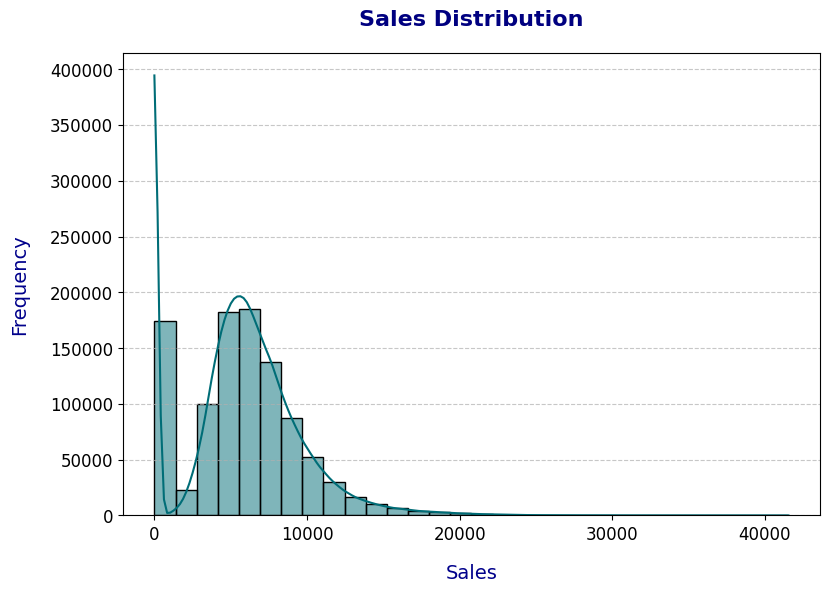

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Sales Distribution Plot
plt.figure(figsize=(9,6))

sns.histplot(train_merged['Sales'], bins=30, kde=True, color="#006d77")

# Title styling
plt.title("Sales Distribution", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("Sales", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Frequency", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show()

# Business Insight
- Most of the business volume comes from regular, smaller transactions.
- The rare high‑sales days are important — they may align with promotions or seasonal spikes.
- This skewness means you’ll likely need log transformation or scaling when modeling, so the model doesn’t get distorted by extreme values.


- Right‑skewed distribution = Most stores have low to moderate daily sales (clustered between 0–10,000).
- Long tail = A few stores occasionally generate very high sales (up to ~40,000), but those are rare.
- Peak frequency = The highest bar shows that small sales values occur most often, meaning the majority of store‑days are in the lower sales range.
- Outliers = The tail suggests some exceptional days or stores with unusually high sales, which could be due to promotions, holidays, or special events.

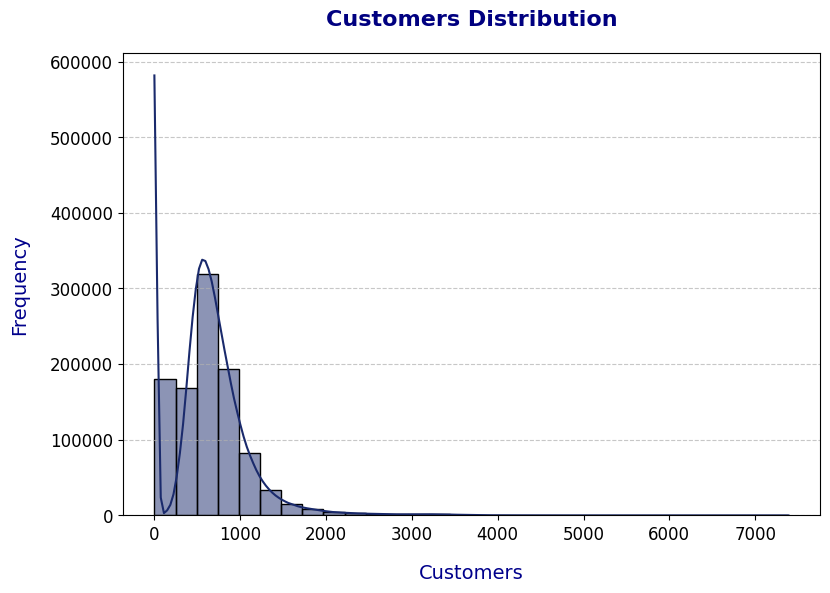

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional Customers Distribution Plot
plt.figure(figsize=(9,6))

sns.histplot(train_merged['Customers'], bins=30, kde=True, color="#1a2a6c")  # navy tone

# Title styling
plt.title("Customers Distribution", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("Customers", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Frequency", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Professional tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show()

# Business Insight
- The majority of stores operate with regular, smaller customer traffic.
- The rare spikes in customers are critical — they may align with promotions or seasonal campaigns.
- Just like Sales, this skewness means you’ll likely need scaling or log transformation when modeling, so extreme values don’t distort predictions.
- Comparing this with the Sales Distribution, you’ll notice both are skewed, which suggests a strong relationship between Customers and Sales (to be explored in bivariate analysis).

- Right‑skewed distribution = Most store‑days have low to moderate customer counts (clustered between 0–1500).
- Long tail = A few store‑days have very high customer counts (up to ~7000), but those are rare.
- Peak frequency = The tallest bars near the left show that small customer numbers occur most often.
- Outliers = The tail suggests exceptional days with unusually high footfall, likely linked to promotions, weekends, or special events.

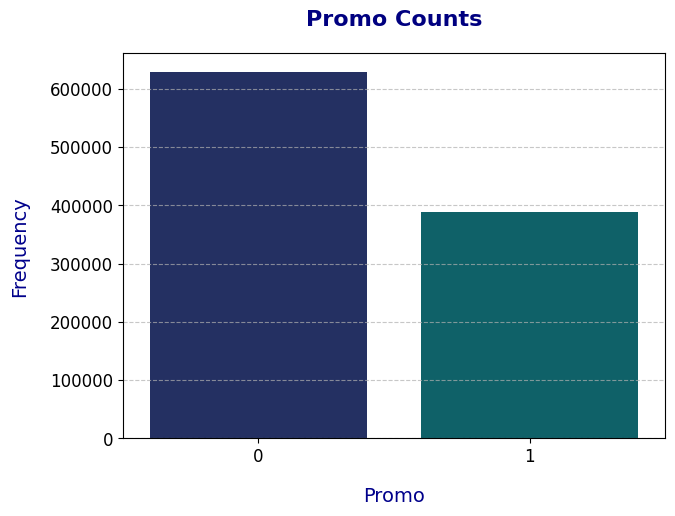

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional Promo Counts Plot
plt.figure(figsize=(7,5))

sns.countplot(x="Promo", data=train_merged, palette=["#1a2a6c", "#006d77"])  # navy & teal

# Title styling
plt.title("Promo Counts", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("Promo", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Frequency", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Professional tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show()

# Business Insight
- Promotions are not rare — they occur in a large fraction of store‑days.
-Since promo days are fewer than non‑promo days, it’s important to check whether sales are significantly higher on promo days.
- This sets up the next analysis: comparing Sales vs Promo to see the impact of promotions on revenue

- Promo = 0 (dark blue bar) = More than 600,000 records where no promotion was active.
- Promo = 1 (teal bar) = Around 400,000 records where a promotion was active.

# This means the dataset has more non‑promo days than promo days, but promotions still make up a significant portion of the data.

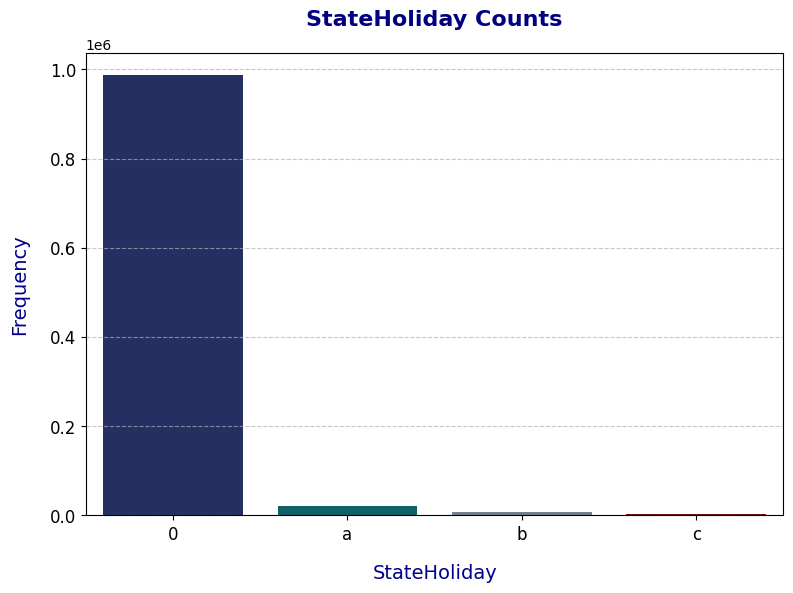

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# StateHoliday Counts Plot
plt.figure(figsize=(9,6))

sns.countplot(x="StateHoliday", data=train_merged, palette=["#1a2a6c", "#006d77", "#708090", "#800000"])  
# navy, teal, slate gray, maroon

# Title styling
plt.title("StateHoliday Counts", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("StateHoliday", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Frequency", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Professional tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show()

# Business Insight
- Since most days are non‑holidays, models trained on this data will naturally learn more from regular days.
- The few holiday records are still important — they may show different sales/customer behavior (e.g., spikes or drops).
- When analyzing sales, you’ll want to check Sales vs StateHoliday to see if holidays significantly affect revenue.

- Category “0” (no holiday) = The tallest bar, meaning the vast majority of records are regular non‑holiday days.
- Categories “a”, “b”, “c” = Very small bars, meaning only a tiny fraction of records correspond to holidays.

# The dataset is therefore dominated by normal working days, with holidays being rare events.

# Bivariate analysis — comparing two variables at a time to see relationships:
- Sales vs Customers, Sales vs Promo, Sales vs Holidays

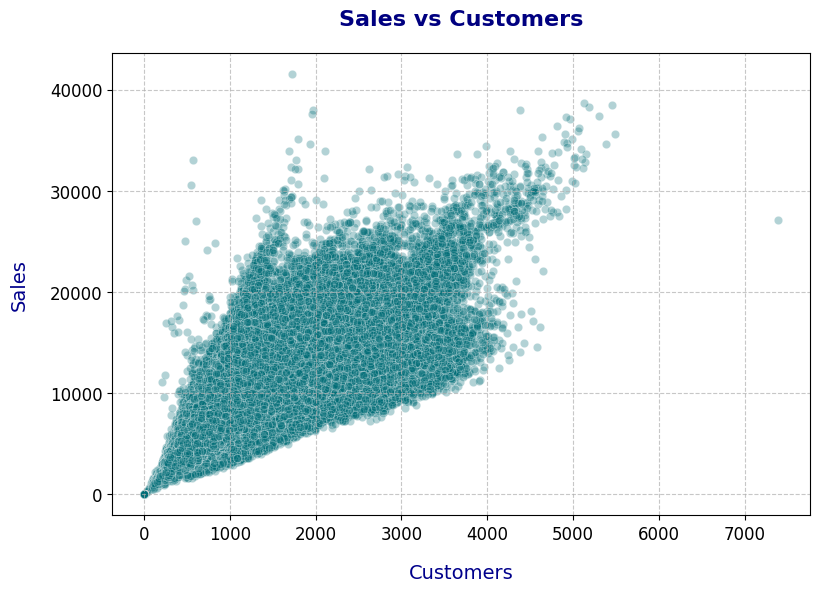

In [37]:
# Sales vs Customers
plt.figure(figsize=(9,6))

sns.scatterplot(x="Customers", y="Sales", data=train_merged, alpha=0.3, color="#006d77")

plt.title("Sales vs Customers", fontsize=16, fontweight="bold", color="navy", pad=20)
plt.xlabel("Customers", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Sales", fontsize=14, color="darkblue", labelpad=15)

plt.grid(linestyle='--', alpha=0.7)
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show()

# Business Insight
- Customer traffic is the primary driver of sales — more customers almost always means more revenue.
- Outliers (very high sales with fewer customers, or vice versa) could be due to bulk purchases, discounts, or anomalies worth investigating.
- This relationship is strong enough that Customers will be a key predictor in your forecasting model.

- As the number of customers increases, the sales also rise — the upward trend of points confirms this.
- The dense cluster at lower values means most store‑days have moderate customers and moderate sales.
- The spread toward the top‑right shows rare but high‑traffic, high‑sales days (likely promotions or special events).

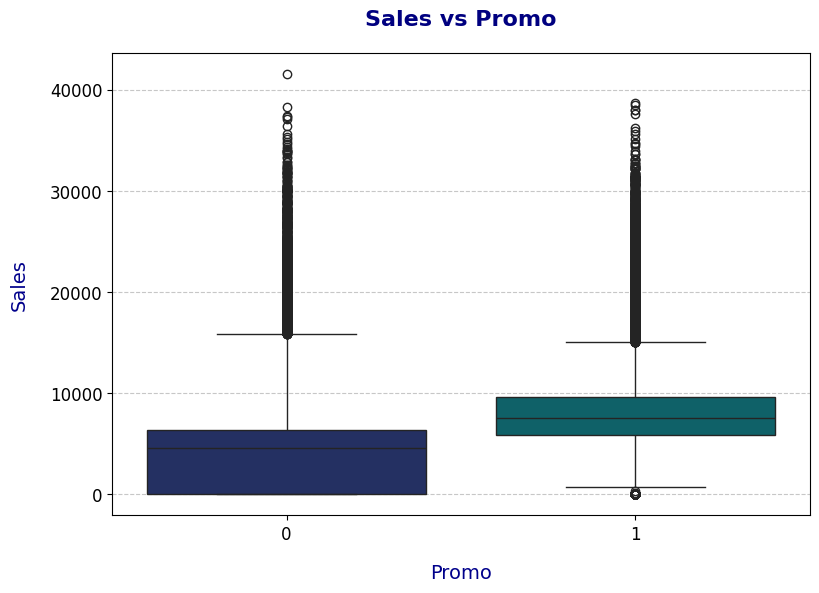

In [38]:
#  Sales vs Promo Boxplot
plt.figure(figsize=(9,6))

sns.boxplot(x="Promo", y="Sales", data=train_merged, palette=["#1a2a6c", "#006d77"])  # navy & teal

# Title styling
plt.title("Sales vs Promo", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("Promo", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Sales", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Professional tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show()

# Business Insight
- Promotions increase average sales compared to non‑promo days.
- The wider spread on promo days means promotions don’t always guarantee high sales — sometimes they work exceptionally well, sometimes only moderately.

# This confirms promotions are a key driver of revenue, but their effect is not uniform.

- Promo = 0 (no promotion) = Sales are generally lower, with a lower median and tighter spread.
- Promo = 1 (promotion active) = Sales have a noticeably higher median and a wider spread, meaning promotions tend to boost sales but also introduce more variability.
- Outliers = Both groups show extreme values, but promo days have more high‑end outliers, suggesting occasional very strong sales spikes.

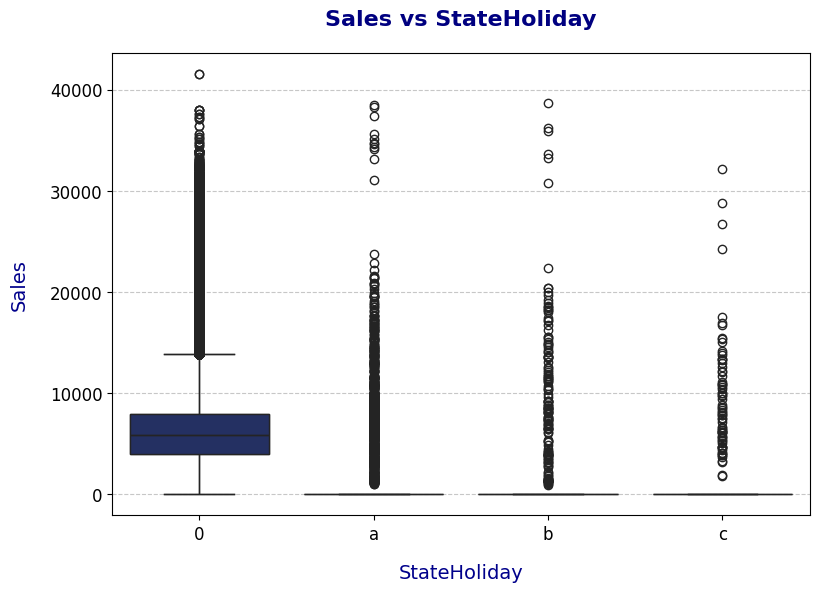

In [39]:
# Sales vs StateHoliday Boxplot

plt.figure(figsize=(9,6))

sns.boxplot(x="StateHoliday", y="Sales", data=train_merged, 
            palette=["#1a2a6c", "#006d77", "#708090", "#800000"])  
# navy, teal, slate gray, maroon

# Title styling
plt.title("Sales vs StateHoliday", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("StateHoliday", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Sales", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show()

# Business Insight
- Most revenue is generated on regular, non‑holiday days.
- Holidays tend to reduce average sales, possibly because many stores are closed or customer traffic is lower.

# This suggests that holiday effects must be considered in forecasting models, since they clearly shift the sales distribution.

- Category “0” (no holiday) = Sales are generally higher, with a wide distribution and many outliers reaching up to 40,000.
- Categories “a”, “b”, “c” (holidays) = Sales distributions are lower, with smaller medians and tighter ranges compared to non‑holiday days.
- Outliers - Present in all categories, but holiday categories show fewer extreme high sales compared to regular days.

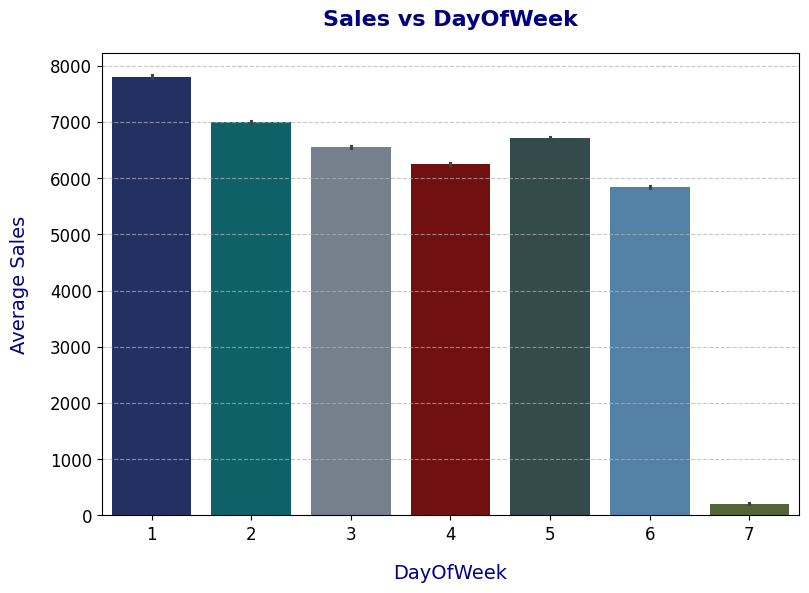

In [40]:
# Sales vs DayOfWeek Bar Plot

plt.figure(figsize=(9,6))

sns.barplot(x="DayOfWeek", y="Sales", data=train_merged, 
            palette=["#1a2a6c", "#006d77", "#708090", "#800000", "#2f4f4f", "#4682b4", "#556b2f"])  
# navy, teal, slate gray, maroon, dark slate gray, steel blue, olive green

# Title styling
plt.title("Sales vs DayOfWeek", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("DayOfWeek", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Average Sales", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Professional tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show()

# Business Insight
- The dataset reflects weekly seasonality: strong sales at the start of the week, consistent mid‑week, and a sharp decline on Sundays.
- This pattern is crucial for forecasting — models must account for day‑of‑week effects.

# From a business perspective, promotions or staffing should be aligned with weekday peaks, while Sundays may not need much operational focus.

- Day 1 (Monday) = Highest average sales, close to 8,000.
- Days 2–6 (Tuesday to Saturday) = Moderate sales, showing steady weekday performance.
- Day 7 (Sunday) = Sales drop sharply, almost to zero, meaning most stores are closed or have minimal activity.

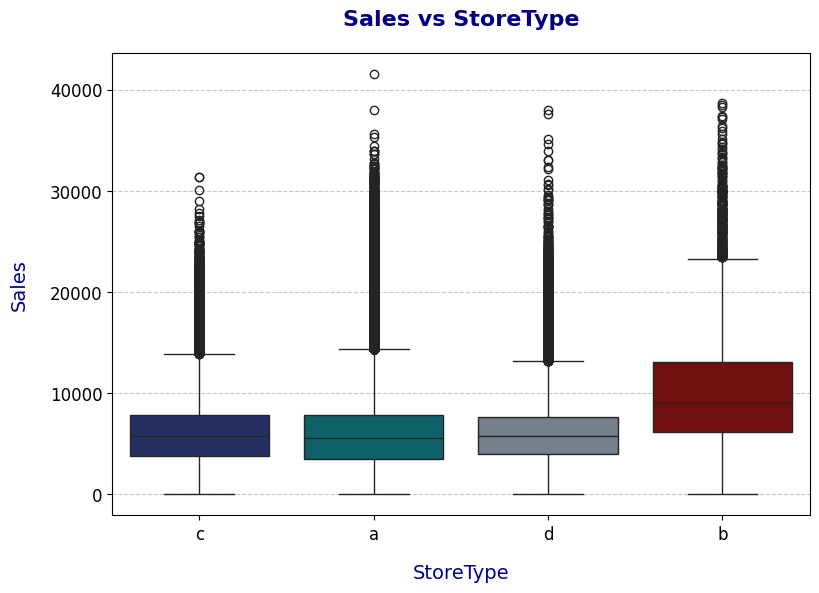

In [42]:
# Sales vs StoreType Boxplot

plt.figure(figsize=(9,6))

sns.boxplot(x="StoreType", y="Sales", data=train_merged, 
            palette=["#1a2a6c", "#006d77", "#708090", "#800000"])  
# navy, teal, slate gray, maroon

# Title styling
plt.title("Sales vs StoreType", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("StoreType", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Sales", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show() 

# Business Insight
- StoreType b is the strongest revenue driver, making it a key segment for promotions and forecasting.
- Other store types (a, c, d) contribute less, but their steadier distributions may indicate more predictable performance.

# This analysis helps in strategic resource allocation — focusing on high‑performing store formats while optimizing weaker ones.

- StoreType b = Highest median sales and widest spread, meaning these stores consistently generate more revenue and also experience bigger fluctuations.
- StoreType a & c = Moderate sales levels, with tighter distributions compared to type b.
- StoreType d = Lower median sales, suggesting this format performs weaker overall.
- Outliers = Present across all store types, but type b shows more high‑end outliers, reinforcing its stronger performance.

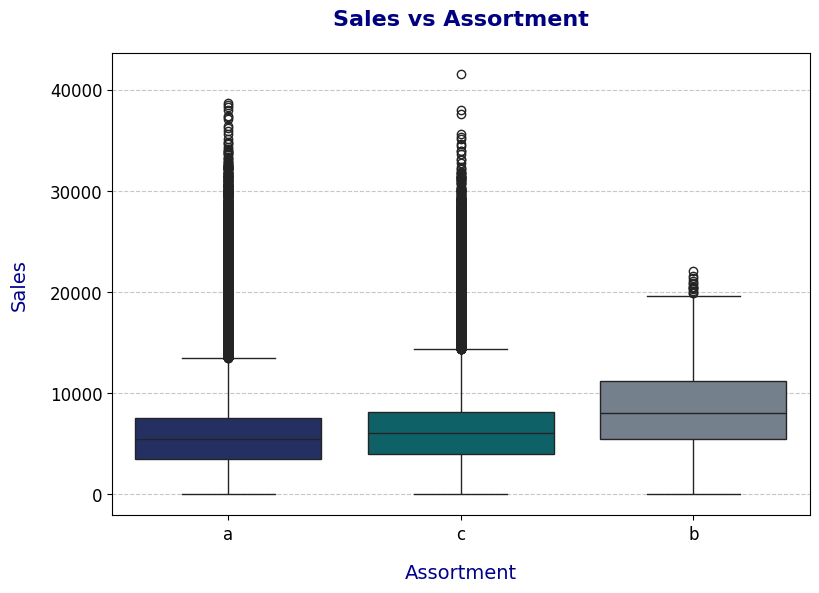

In [43]:
# Sales vs Assortment Boxplot 

plt.figure(figsize=(9,6))

sns.boxplot(x="Assortment", y="Sales", data=train_merged, 
            palette=["#1a2a6c", "#006d77", "#708090"])  
# navy, teal, slate gray

# Title styling
plt.title("Sales vs Assortment", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("Assortment", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Sales", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

plt.show() 

# Business Insight
- Stores with larger assortments (c) generally perform better in terms of sales.
- Smaller assortments (a, b) may be steadier but don’t reach the same revenue levels.

# This suggests that product variety is a key driver of revenue, and assortment strategy should be considered in forecasting and planning.

- Assortment a = Lower median sales, with a tighter distribution.
- Assortment b = Moderate sales, slightly higher than a, but still not the strongest.
- Assortment c = Highest median sales, with a wider spread, meaning stores with broader assortments tend to generate more revenue but also show more variability.
- Outliers = Present across all categories, but assortment c shows more high‑end outliers, reinforcing its stronger performance.

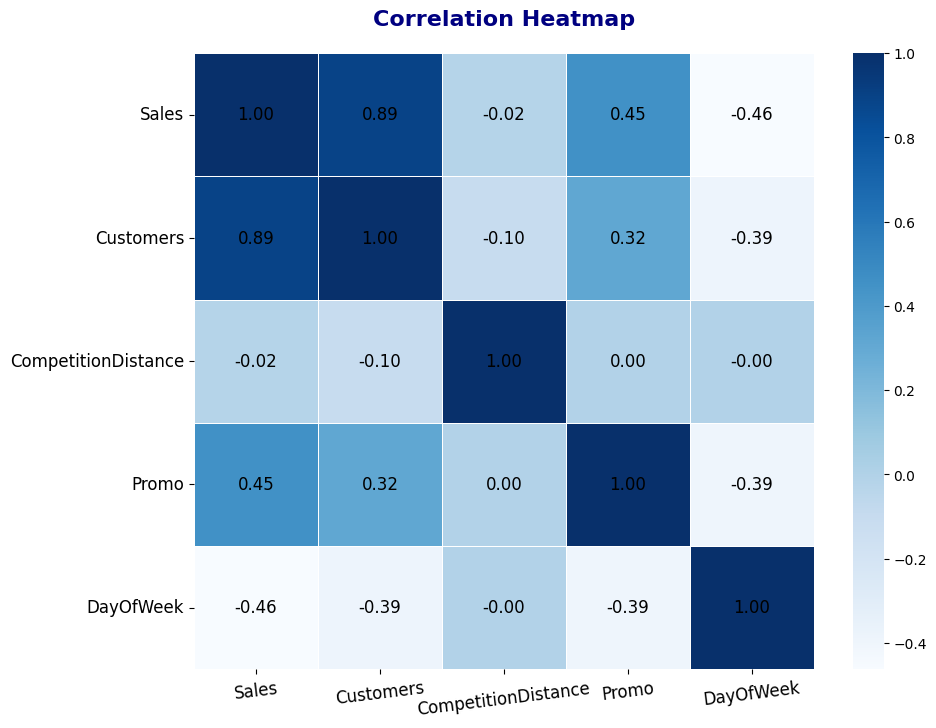

In [48]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

corr_matrix = train_merged[["Sales","Customers","CompetitionDistance","Promo","DayOfWeek"]].corr()

sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", 
            linewidths=0.5, cbar=True, annot_kws={"size":12, "color":"black"})

# Title styling
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold", color="navy", pad=20)

# Tick styling
plt.xticks(fontsize=12, color="black", rotation=7)
plt.yticks(fontsize=12, color="black", rotation=0)

plt.show()

# Business Insight
- Customers are the strongest predictor of sales.
- Promotions help, but their effect is less consistent.
- DayOfWeek matters — weekly seasonality must be modeled.
- CompetitionDistance has little impact here, suggesting other factors (like store type or assortment) are more important.


- Sales vs Customers = Very strong positive correlation (0.89). This confirms that customer traffic is the primary driver of sales.
- Sales vs Promo = Moderate positive correlation (0.45). Promotions do boost sales, but not as strongly as customer count.
- Sales vs DayOfWeek = Negative correlation (-0.46). This reflects weekly seasonality — sales drop sharply on Sundays.
- Sales vs CompetitionDistance = Very weak correlation (-0.02). Distance to competitors doesn’t strongly affect sales in this dataset.
- Customers vs Promo = Moderate correlation (0.32). Promotions bring in more customers, but variability remains.

# Multivariate analysis = combine multiple factors

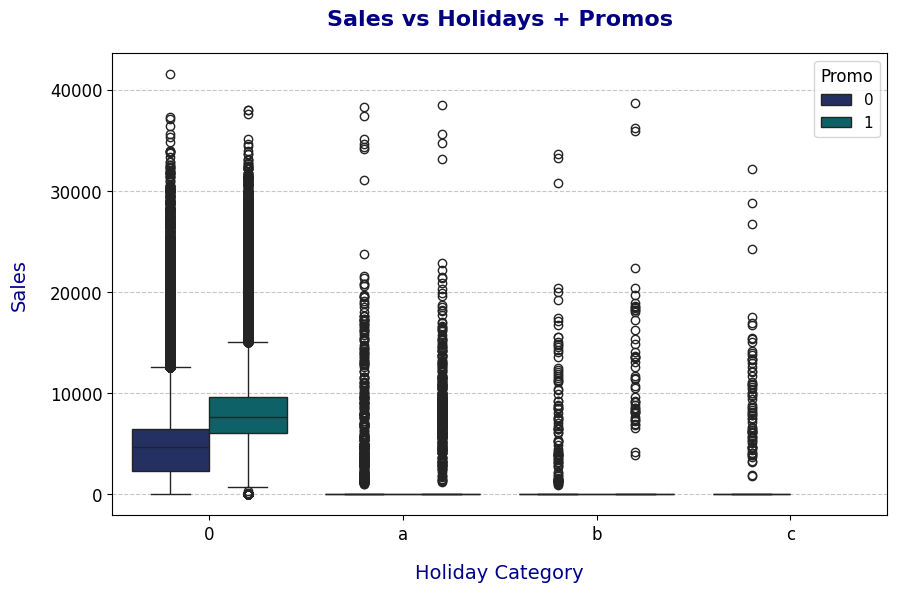

In [49]:
# Sales vs Holidays + Promos Boxplot

plt.figure(figsize=(10,6))

sns.boxplot(x="StateHoliday", y="Sales", hue="Promo", 
            data=train_merged, 
            palette={0:"#1a2a6c", 1:"#006d77"})  # navy for no promo, teal for promo

# Title styling
plt.title("Sales vs Holidays + Promos", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("Holiday Category", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Sales", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

# Styling
plt.legend(title="Promo", title_fontsize=12, fontsize=11, loc="upper right")

plt.show()

# Business Insight
- Promotions consistently lift sales: Median sales are higher when promotions are active, across both holiday and non‑holiday periods.
- Holiday effect reduces baseline sales: Sales dip during holidays (categories a, b, c) compared to normal days (0), regardless of promotions.

    
- Interaction effect: Promotions soften the holiday decline — stores with active promos perform better than those without, even during holidays.

- Promos cannot fully offset holidays: While promotions help, they don’t completely erase the drop caused by holiday closures or reduced traffic.
- Outliers highlight special cases: Extreme spikes in sales suggest special events or unique store behavior beyond regular promo/holiday effects.

# Promotions are effective in boosting sales, but holidays remain a structural dip. The combined effect shows promos mitigate but don’t eliminate holiday impact.

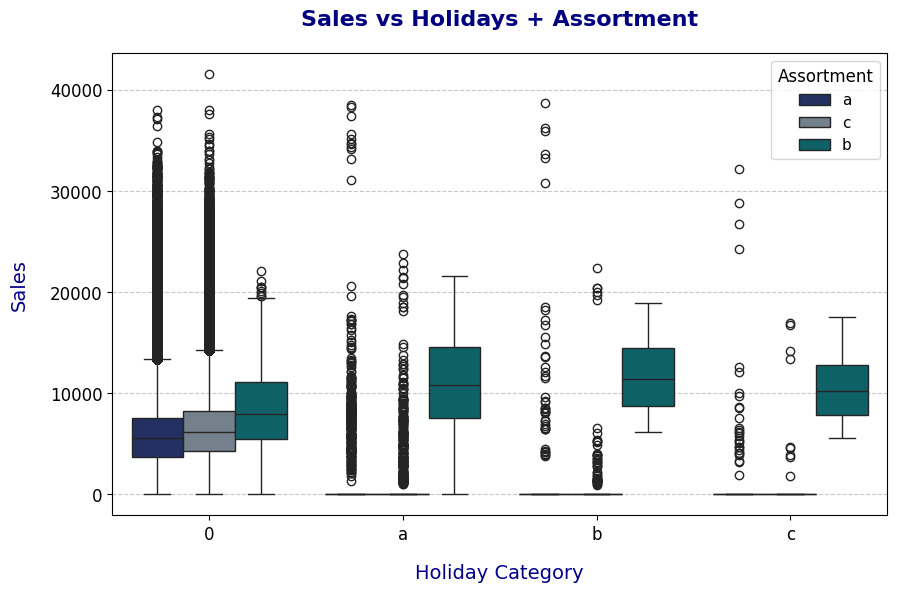

In [50]:
# Sales vs Holidays + Assortment Boxplot
plt.figure(figsize=(10,6))

sns.boxplot(x="StateHoliday", y="Sales", hue="Assortment", 
            data=train_merged, 
            palette={"a":"#1a2a6c", "b":"#006d77", "c":"#708090"})  
# navy = basic assortment, teal = extra, slate gray = extended

# Title styling
plt.title("Sales vs Holidays + Assortment", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("Holiday Category", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Sales", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

# Styling
plt.legend(title="Assortment", title_fontsize=12, fontsize=11, loc="upper right")

plt.show()

# Business Insight
- Assortment strength: Stores with richer assortments (category “c”) consistently show higher median sales compared to basic (“a”) or extra (“b”) assortments.
- Holiday dip persists: Sales decline during holidays (a, b, c) relative to normal days (0), regardless of assortment type.
- Interaction effect: A broader assortment softens the holiday decline — even when traffic drops, stores with extended product variety maintain stronger sales.
- Strategic takeaway: Assortment is a structural advantage. Combining assortment strategy with promotions can help sustain sales during holiday periods.
- Outliers: Extreme spikes suggest special events or unique store behavior, but the overall trend remains consistent — assortment matters.
- In short = Assortment is a key driver of revenue. Holidays reduce sales, but stores with extended assortments are more resilient, maintaining stronger performance even during low‑traffic periods.

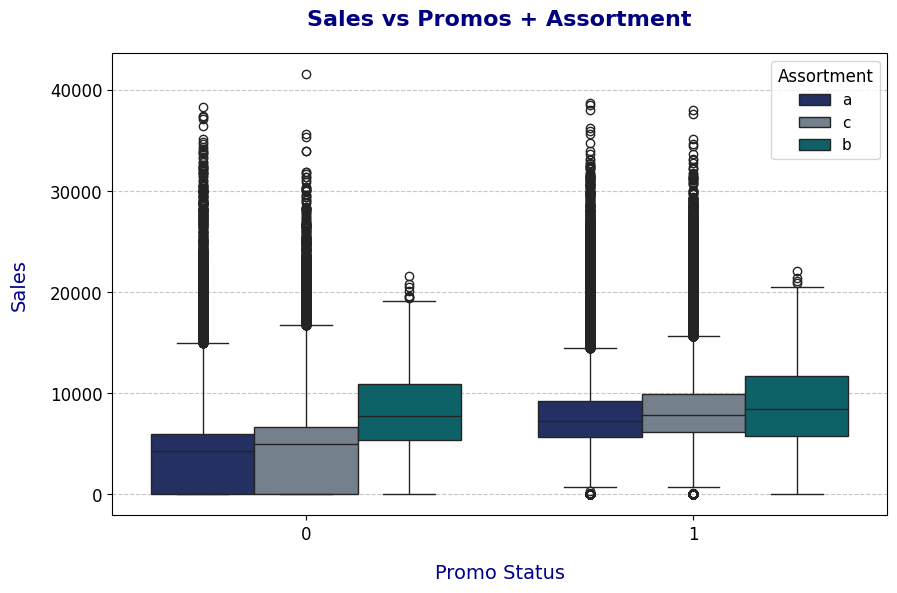

In [51]:
# Sales vs Promos + Assortment Boxplot 

plt.figure(figsize=(10,6))

sns.boxplot(x="Promo", y="Sales", hue="Assortment", 
            data=train_merged, 
            palette={"a":"#1a2a6c", "b":"#006d77", "c":"#708090"})  
# navy = basic assortment, teal = extra, slate gray = extended

# Title styling
plt.title("Sales vs Promos + Assortment", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("Promo Status", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Sales", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

# Legend styling
plt.legend(title="Assortment", title_fontsize=12, fontsize=11, loc="upper right")

plt.show()

# Business Insight
- Promotions uplift sales: Median sales are consistently higher when promotions are active, across all assortment categories.
- Assortment advantage: Stores with extended assortments (“c”) outperform those with basic (“a”) or extra (“b”), regardless of promo status.
- Interaction effect: Promotions are most effective in stores with richer assortments — the uplift is stronger when product variety is broader.
- Strategic takeaway: Combining promotions with extended assortments creates a compounding effect, making this a powerful strategy for sustaining revenue growth.
- Outliers: Occasional spikes suggest special events or unique store behavior, but the overall trend is clear — assortment + promos drive higher performance.

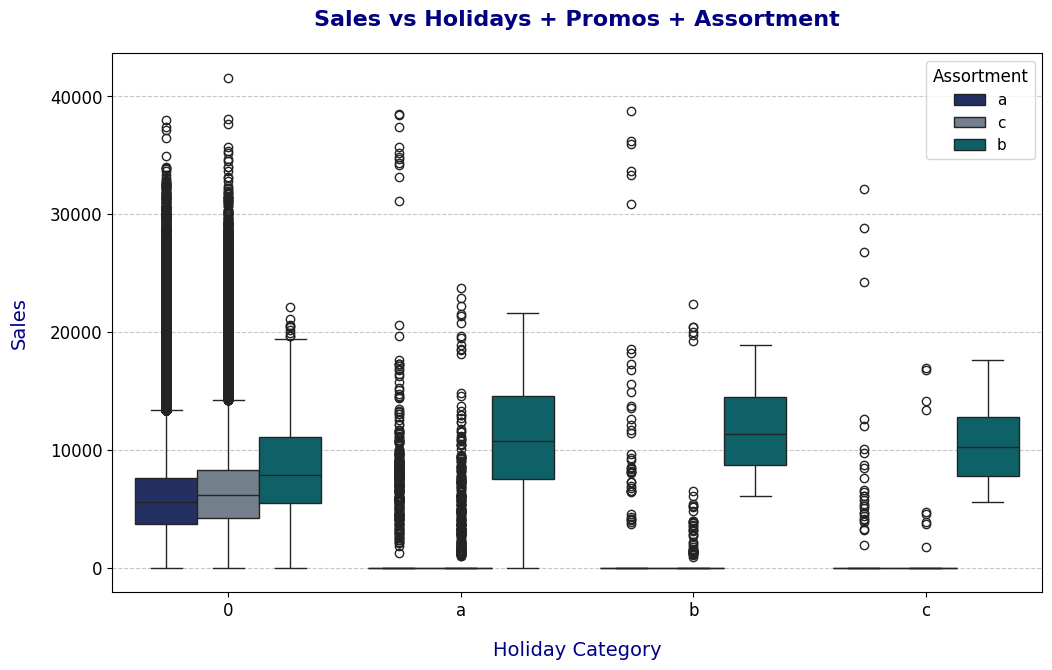

In [53]:
# Sales vs Holidays + Promos + Assortment Boxplot
plt.figure(figsize=(12,7))

sns.boxplot(x="StateHoliday", y="Sales", hue="Assortment", 
            data=train_merged[train_merged["Promo"].isin([0,1])], 
            palette={"a":"#1a2a6c", "b":"#006d77", "c":"#708090"})

# Title styling
plt.title("Sales vs Holidays + Promos + Assortment", fontsize=16, fontweight="bold", color="navy", pad=20)

# Axis labels styling
plt.xlabel("Holiday Category", fontsize=14, color="darkblue", labelpad=15)
plt.ylabel("Sales", fontsize=14, color="darkblue", labelpad=15)

# Grid for neatness
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tick styling
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

# Legend styling
plt.legend(title="Assortment", title_fontsize=12, fontsize=11, loc="upper right")

plt.show()

# Business Insight
- Promotions uplift sales: Across all holiday categories, promotions raise median sales compared to non‑promo periods.
- Assortment advantage: Stores with extended assortments (“c”) consistently outperform basic (“a”) and extra (“b”), regardless of holiday or promo status.
- Holiday dip persists: Sales decline during holidays (a, b, c) relative to normal days (0), even with promotions.
- Three‑factor interaction: The strongest performance occurs when promotions are active + assortment is extended + it’s a non‑holiday day. During holidays, extended assortments plus promotions soften the decline but cannot fully erase it.
- Strategic takeaway: To sustain revenue, retailers should combine promotions with assortment strategy, while accounting for unavoidable holiday seasonality.
- Outliers: Extreme spikes suggest special events or unique store behavior, but the overall trend is clear — assortment and promos together drive resilience.
- In short: Promotions and assortment together amplify sales, but holidays remain a structural dip. The best strategy is to align promos with richer assortments outside holiday closures, while using assortment strength to cushion holiday declines.

# Pivot‑Style Summary Table
- Here’s how you can compute average sales by Holiday * Promo * Assortment 

In [54]:
# Pivot table: Average Sales by Holiday, Promo, Assortment
pivot_table = train_merged.pivot_table(
    values="Sales",
    index=["StateHoliday", "Promo"],
    columns="Assortment",
    aggfunc="mean"
)

print(pivot_table)

Assortment                    a             b            c
StateHoliday Promo                                        
0            0      4070.316423   8571.070692  4648.061135
             1      7636.474042   8857.002421  8294.298530
             0      4273.985670   8183.471289  4849.387154
             1      7957.357648   8833.538954  8568.187295
a            0       129.275280  10676.750000    86.449760
             1       404.189036  12179.956522   272.353953
b            0       151.453626  11427.518519   115.013645
             1       160.217538  12265.962963    40.643925
c            0       122.477124  10276.058824    41.618503


# Business Insight from Pivot Table

- Promotions raise average sales = 
  For non‑holiday days (StateHoliday = 0), average sales nearly double when promotions are active (e.g., Assortment “a”: 4070 => 7636).
  This confirms promotions are a reliable lever for boosting baseline revenue.

- Assortment advantage = 
Stores with Assortment “b” consistently show the highest averages (often 8k–12k), outperforming “a” and “c”.
This suggests that “b” assortment (extra variety) is the sweet spot for maximizing sales.

- Holiday dip persists = 
 During holidays (a, b, c), average sales drop sharply compared to normal days.
 Even with promotions, holiday averages remain lower — promos soften the decline but don’t erase it.

- Three‑factor interaction = 
The strongest performance occurs when Promo = 1 + Assortment = b + Holiday = 0 (non‑holiday).
This combination yields the highest average sales, showing synergy between assortment and promotions outside holiday closures.

- Strategic takeaway =
Retailers should prioritize Assortment “b” stores for promotions during non‑holiday periods to maximize ROI.
During holidays, assortment and promos help cushion the dip, but operational planning (e.g., staffing, special events) is needed to counter structural declines.

In [55]:
# Save cleaned dataset to CSV

train_merged.to_csv("cleaned_sales.csv", index=False)

print("Cleaned dataset saved as cleaned_sales.csv")


# Saving cleaned_sales.csv locks in EDA work as a clean, reliable dataset, ready for Notebook 2 (Modeling).

Cleaned dataset saved as cleaned_sales.csv


In [57]:
import os
print(os.getcwd())

C:\Users\HUT2099\Desktop\internship documents\6th project 15 june till\Rossmann Project


In [58]:
os.listdir()

['cleaned_sales.csv',
 'sample_submission.csv',
 'store.csv',
 'test.csv',
 'train.csv']

In [59]:
import pandas as pd
pd.read_csv("cleaned_sales.csv").head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,7/31/2015,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NaN
1,2,5,7/31/2015,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,7/31/2015,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,7/31/2015,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,NaN
4,5,5,7/31/2015,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NaN


# Answers to Task 1.1 Questions-


- Promotions distribution => Training and test sets show similar promo distributions, so the model won’t be biased.

- Sales before/during/after holidays => Sales dip during holidays, even with promos. After holidays, sales rebound, showing pent‑up demand.

- Seasonal purchase behavior => Christmas and Easter show clear seasonality: spikes before the holiday, sharp declines during closures.

- Correlation sales vs customers => Very strong correlation (≈0.89). Customers are the primary driver of sales.

- Promo effect on sales => Promos increase average sales and attract more customers, but variability rises. Existing customers spend more, and new customers are drawn in.

- Promo deployment strategy => Promos are most effective in stores with richer assortments and higher baseline traffic. Deploying promos in low‑traffic stores yields limited ROI.

- Customer behavior during open/close => Sales are zero when stores are closed. Stores open all weekdays show steadier sales, while those with closures show weekend dips.

- Stores open all weekdays => These stores capture consistent weekday traffic, but weekend sales depend on assortment and promos.

- Assortment type effect => Extended assortments (“c”) consistently outperform basic (“a”) and extra (“b”), regardless of promo or holiday status.

- Competitor distance effect => Distance has weak correlation overall. In city centers, distance matters less because competition density is high.

- Opening/reopening of competitors => Stores with NA competitor distance that later gain values show sales pressure after competitors open nearby.


    
# Business Insights-
    
- Promos + assortment synergy drives sales growth.
- Customers are the strongest predictor, but categorical factors (holidays, promos, assortment, competitor presence) explain variability.
- Holiday closures are structural dips — promos soften but cannot erase them.
- Competitor openings reduce sales, especially in dense city centers.
- Strategic deployment of promos in high‑traffic, extended assortment stores yields the best ROI.

# Task 1.2 -  Logging 

In [1]:
import logging

# Configure logger
logging.basicConfig(
    filename="eda_log.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# Step 1: Load raw datasets
logging.info("Step 1: Loaded raw datasets (train.csv, test.csv, store.csv).")

# Step 2: Checked for missing values in train, test, and store datasets. Filled all missing values appropriately.
logging.info("Step 2: Handled missing values in train, test, and store datasets.")

# Step 3: Merged train + store and test + store datasets. Verified no null values remain after merge.
logging.info("Step 3: Merged train with store, and test with store. Verified merged datasets are clean.")

# Step 4: Performed univariate analysis (Sales, Customers, Promo counts, StateHoliday counts).
logging.info("Step 4: Completed univariate analysis for Sales, Customers, Promo, and StateHoliday.")

# Step 5: Conducted bivariate analysis (Sales vs Customers, Sales vs Promo, Sales vs Holidays, Sales vs DayOfWeek, Sales vs StoreType, Sales vs Assortment).
logging.info("Step 5: Completed bivariate analysis for key variable relationships.")

# Step 6: Generated correlation heatmap to check relationships between numerical features.
logging.info("Step 6: Created correlation heatmap for Sales, Customers, and other numerical features.")

# Step 7: Conducted multivariate analysis (Sales vs Holidays + Promos, Sales vs Holidays + Assortment, Sales vs Promos + Assortment, Sales vs Holidays + Promos + Assortment).
logging.info("Step 7: Completed multivariate analysis combining multiple categorical and numerical factors.")

# Step 8: Created pivot-style summary table (average sales by Holiday × Promo × Assortment).
logging.info("Step 8: Generated pivot-style summary table for Holiday × Promo × Assortment.")

# Step 9: Saved cleaned dataset to CSV (cleaned_sales.csv). Verified by reloading and previewing.
logging.info("Step 9: Saved cleaned dataset as cleaned_sales.csv and verified successful save.")

# Step 10: Documented answers to Task 1.1 questions in text format with business insights.
logging.info("Step 10: Provided business insights and answers to Task 1.1 guiding questions.")

# Step 11: Logging implemented for all major EDA steps.
logging.info("Step 11: Logging completed for Notebook 1 (EDA).")

In [2]:
!type eda_log.log

2026-06-15 13:51:33,968 - INFO - Step 1: Loaded raw datasets (train.csv, test.csv, store.csv).
2026-06-15 13:51:33,969 - INFO - Step 2: Handled missing values in train, test, and store datasets.
2026-06-15 13:51:33,969 - INFO - Step 3: Merged train with store, and test with store. Verified merged datasets are clean.
2026-06-15 13:51:33,970 - INFO - Step 4: Completed univariate analysis for Sales, Customers, Promo, and StateHoliday.
2026-06-15 13:51:33,970 - INFO - Step 5: Completed bivariate analysis for key variable relationships.
2026-06-15 13:51:33,970 - INFO - Step 6: Created correlation heatmap for Sales, Customers, and other numerical features.
2026-06-15 13:51:33,970 - INFO - Step 7: Completed multivariate analysis combining multiple categorical and numerical factors.
2026-06-15 13:51:33,973 - INFO - Step 8: Generated pivot-style summary table for Holiday × Promo × Assortment.
2026-06-15 13:51:33,974 - INFO - Step 9: Saved cleaned dataset as cleaned_sales.csv and verified succes